# ARMA: one recursion for fitting and forecasting

An ARMA(1,1) model feeds both the previous observation and the previous prediction
error into its next prediction. This is the smallest example of the `ssoe`
(single source of error) helper. Synthetic data let us inspect parameter recovery,
and a rolling-origin backtest checks predictions on multiple held-out windows.

Inspired by [Juan Orduz's ARMA notebook](https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/arma.ipynb).
The implementation uses PyMC parameters, named coordinates, and one shared update rule.

In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr

from pymc_forecast import (
    HMCForecaster,
    backtest,
    evaluate_forecast,
    results_to_dataframe,
    ssoe,
)

SMOKE = os.getenv("PYMC_FORECAST_SMOKE_TEST") == "1"
SEED = 2026
rng = np.random.default_rng(SEED)
DRAWS, TUNE, CHAINS = (25, 25, 1) if SMOKE else (600, 800, 2)
N_PRED = 50 if SMOKE else 800
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})
print(
    "Execution mode:", "CI smoke check; do not interpret fit quality" if SMOKE else "full example"
)

Execution mode: full example


## Simulate a known process

In [2]:
phi_true, theta_true, sigma_true = 0.65, 0.25, 0.4
n_train, horizon = 140, 24
errors = rng.normal(0, sigma_true, n_train + horizon)
values = np.zeros(n_train + horizon)
previous_y = previous_error = 0.0
for i, error in enumerate(errors):
    values[i] = phi_true * previous_y + theta_true * previous_error + error
    previous_y, previous_error = values[i], error
series = xr.DataArray(
    values, dims="time", coords={"time": pd.date_range("2024-01-01", periods=len(values), freq="D")}
)
train = series.isel(time=slice(n_train))
truth = series.isel(time=slice(n_train, None)).rename(time="time_future")

## Define the recursion

$\mu_t=\phi y_{t-1}+\theta\epsilon_{t-1}$ and $y_t=\mu_t+\epsilon_t$.
During training, the filter computes errors from observations. During forecasting,
`eps_future` is absent from the posterior and is sampled anew; simulated observations
and errors update the same state. Stationarity and invertibility are enforced here
by bounding the two coefficients. Initial observation and error are fixed at zero,
matching this simulation; real data may call for an inferred initial state.

`ssoe` registers only future errors. We explicitly register the likelihood and
predictions, so future observation noise is included exactly once.

In [3]:
def arma_model(h, covariates):
    phi = pm.Uniform("phi", -0.95, 0.95)
    theta = pm.Uniform("theta", -0.95, 0.95)
    sigma = pm.HalfNormal("sigma", 1.0)

    def mean(state, x, phi, theta):
        previous_y, previous_error = state
        return phi * previous_y + theta * previous_error

    def update(state, y, error, x, phi, theta):
        return y, error

    r = ssoe(
        h,
        "eps",
        (0.0, 0.0),
        mean,
        update,
        lambda name, dims: pm.Normal(name, 0, sigma, dims=dims),
        params=(phi, theta),
    )
    pm.Normal("obs", r.mu, sigma, observed=h.data.values, dims="time")
    pm.Deterministic("mu", r.mu, dims="time")
    if h.future:
        pm.Deterministic("mu_future", r.mu_future, dims="time_future")
        pm.Deterministic("forecast", r.y_future, dims="time_future")

## Fit and inspect parameter recovery

In [4]:
fc = HMCForecaster(
    arma_model,
    train,
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    random_seed=SEED,
    progressbar=False,
    sample_kwargs={"target_accept": 0.9},
)
summary = az.summary(fc.idata, var_names=["phi", "theta", "sigma"])
summary["simulation_truth"] = [phi_true, theta_true, sigma_true]
summary

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [phi, theta, sigma]


Sampling 2 chains for 800 tune and 600 draw iterations (1_600 + 1_200 draws total) took 15 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,simulation_truth
phi,0.689,0.075,0.551,0.821,0.003,0.002,727.0,576.0,1.0,0.65
theta,0.298,0.092,0.125,0.469,0.003,0.003,899.0,816.0,1.0,0.25
sigma,0.429,0.026,0.383,0.480,0.001,0.001,960.0,995.0,1.0,0.40


## Forecast with one fixed set of posterior draws

`mu_future` excludes each step's current observation error. It still varies with
errors simulated at earlier future steps. This is the conditional one-step mean,
not an unconditional multi-step expectation that integrates all future errors.

In [5]:
posterior = fc.draw_posterior(N_PRED, random_seed=SEED + 1)
pred = fc.forecast(horizon=horizon, posterior=posterior, random_seed=SEED + 2).predictions
np.testing.assert_allclose(pred.forecast - pred.mu_future, pred.eps_future)
assert pred.forecast.dims == ("chain", "draw", "time_future")
pd.Series(evaluate_forecast(pred.forecast, truth))

Sampling: [eps_future]


mae         0.569283
rmse        0.724103
crps        0.409667
coverage    0.875000
dtype: float64

In [6]:
def plot_forecast(ax, samples, truth, label="forecast", color="C0"):
    time = samples.time_future.values
    q = samples.quantile([0.05, 0.5, 0.95], dim=("chain", "draw"))
    ax.fill_between(
        time,
        q.sel(quantile=0.05),
        q.sel(quantile=0.95),
        alpha=0.2,
        color=color,
        label=f"{label}: 90% interval",
    )
    ax.plot(time, q.sel(quantile=0.5), color=color, label=f"{label}: median")
    ax.plot(time, truth.values, color="black", lw=1, label="held-out observations")
    ax.set(xlabel="Date", ylabel="Value")
    ax.legend(loc="upper left")

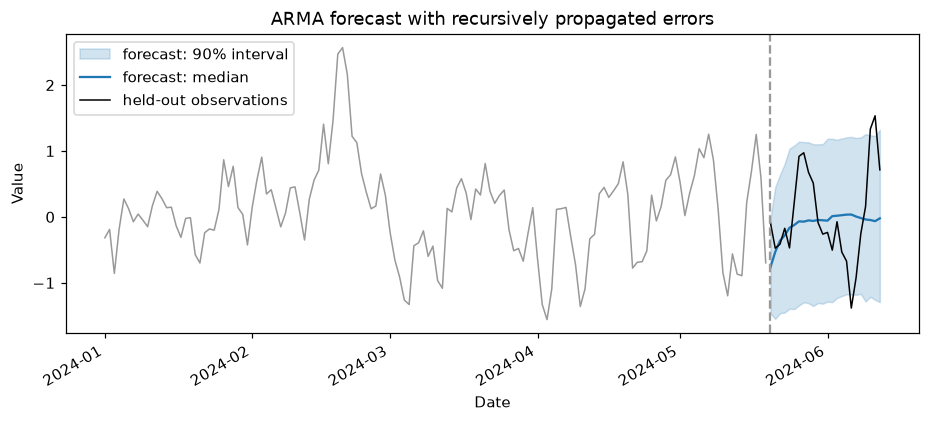

In [7]:
fig, ax = plt.subplots()
plot_forecast(ax, pred.forecast, truth)
ax.plot(train.time, train, color="0.6", lw=1)
ax.axvline(truth.time_future.values[0], color="0.6", ls="--")
ax.set_title("ARMA forecast with recursively propagated errors")
fig.autofmt_xdate()
plt.show()

## Expanding-window backtest

Every fold refits on its own history; the errors of the held-out observations never
enter the recursion. Scores include observation noise and are computed on the
original scale. Two small folds keep this example inexpensive.

In [8]:
results = backtest(
    series,
    None,
    arma_model,
    forecaster_cls=HMCForecaster,
    min_train_window=116,
    test_window=24,
    stride=24,
    num_samples=N_PRED,
    forecaster_options={
        "draws": DRAWS,
        "tune": TUNE,
        "chains": CHAINS,
        "progressbar": False,
        "sample_kwargs": {"target_accept": 0.9},
    },
    keep_predictions=True,
    random_seed=SEED + 3,
)
results_to_dataframe(results)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [phi, theta, sigma]


Sampling 2 chains for 800 tune and 600 draw iterations (1_600 + 1_200 draws total) took 14 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

NUTS: [phi, theta, sigma]


Sampling 2 chains for 800 tune and 600 draw iterations (1_600 + 1_200 draws total) took 12 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


Sampling: [eps_future]


,t0,t1,t2,num_samples,train_walltime,test_walltime,mae,rmse,crps,coverage
0,0,116,140,800,17.452057,0.461012,0.643081,0.733311,0.427093,0.916667
1,0,140,164,800,13.869391,0.443786,0.553600,0.712774,0.403901,0.833333


## What to inspect

Check coefficient recovery and NUTS diagnostics before interpreting the forecasts.
Compare coverage across folds as well as CRPS; a single test segment is noisy.
The package tests additionally compare predictive variances against the analytical
ARMA impulse-response formula, which catches implementations that drop future errors.